In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import coint

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [2]:
# Load raw macroeconomic dataset
df = pd.read_csv("master_dataset_v20260306.csv")

# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Set Date as index
df = df.set_index("Date").sort_index()

# Restrict sample to post-1986 period (better data availability)
df = df[df.index >= "1986-01-01"]

# Check structure
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (161, 14)


,USRECD,T10Y2Y,UNRATE,INDPRO,CPIAUCSL,TEDRATE,BAA10Y,FEDFUNDS,Target_1Q_ahead,Target_2Q_ahead,Target_3Q_ahead,BAA10Y_missing,T10Y2Y_missing,FEDFUNDS_missing
Date,,,,,,,,,,,,,,
1986-01-01,0.0,0.789333,7.033333,55.355800,109.566667,1.012034,2.452667,7.826667,0.0,0.0,0.0,0,0,0
1986-04-01,0.0,0.620156,7.166667,55.021467,109.033333,0.859048,2.672656,6.920000,0.0,0.0,0.0,0,0,0
1986-07-01,0.0,0.855781,6.966667,55.237800,109.700000,0.766984,2.877031,6.206667,0.0,0.0,0.0,0,0,0
1986-10-01,0.0,0.988226,6.833333,55.857800,110.466667,0.808197,2.828065,6.266667,0.0,0.0,0.0,0,0,0
1987-01-01,0.0,0.844262,6.600000,56.608500,111.800000,0.847705,2.466393,6.220000,0.0,0.0,0.0,0,0,0


We load the raw macroeconomic dataset constructed in the data infrastructure pipeline.

For the exploratory analysis we focus on the post-1986 period.  
Earlier observations contain substantial missing values for some financial indicators and belong to a different macroeconomic regime.

Using a consistent modern sample improves interpretability and avoids distortions in correlation and lead–lag analysis.

## 1. Dataset Overview

We first inspect the dataset structure to understand the time coverage, number of observations and potential missing values.

The dataset contains quarterly macroeconomic indicators from 1986 onwards, which corresponds to a modern macroeconomic regime with relatively complete data coverage for financial variables such as credit spreads and interest rates.

In [3]:
df.info()

print("\nNumber of observations:", len(df))
print("Date range:", df.index.min(), "to", df.index.max())

# Check missing values
print("\nMissing values by variable:")
print(df.isna().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 161 entries, 1986-01-01 to 2026-01-01
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   USRECD            161 non-null    float64
 1   T10Y2Y            161 non-null    float64
 2   UNRATE            161 non-null    float64
 3   INDPRO            161 non-null    float64
 4   CPIAUCSL          161 non-null    float64
 5   TEDRATE           145 non-null    float64
 6   BAA10Y            161 non-null    float64
 7   FEDFUNDS          161 non-null    float64
 8   Target_1Q_ahead   160 non-null    float64
 9   Target_2Q_ahead   159 non-null    float64
 10  Target_3Q_ahead   158 non-null    float64
 11  BAA10Y_missing    161 non-null    int64  
 12  T10Y2Y_missing    161 non-null    int64  
 13  FEDFUNDS_missing  161 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 18.9 KB

Number of observations: 161
Date range: 1986-01-01 00:00:00 to 2026-01-

### Summary Statistics

The summary statistics provide a first overview of the distribution of macroeconomic indicators.

In particular, financial indicators such as the yield curve spread and credit spreads exhibit substantial variation across the sample, reflecting changing financial conditions over the business cycle.

In [4]:
# Summary statistics of macroeconomic indicators
summary_stats = df.describe().T

summary_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
USRECD,0.086957,0.282650,0.000000,0.000000,0.000000,0.000000,1.000000
T10Y2Y,0.966822,0.880526,-0.766984,0.250625,0.844262,1.688167,2.800164
UNRATE,5.696377,1.660514,3.533333,4.433333,5.433333,6.600000,13.000000
INDPRO,87.306561,15.436232,55.021467,73.290900,92.878333,99.988267,104.049100
CPIAUCSL,201.654901,57.445892,109.033333,155.066667,199.466667,237.855000,326.588000
TEDRATE,0.541791,0.401709,0.076349,0.252540,0.455410,0.684167,2.446721
BAA10Y,2.273112,0.678490,1.367869,1.751587,2.126885,2.666562,5.580968
FEDFUNDS,3.349337,2.649432,0.060000,0.506667,3.256667,5.330000,9.726667
Target_1Q_ahead,0.087500,0.283454,0.000000,0.000000,0.000000,0.000000,1.000000
Target_2Q_ahead,0.088050,0.284263,0.000000,0.000000,0.000000,0.000000,1.000000


## 2. Multivariate Exploratory Data Analysis

In this section we explore the relationships among macroeconomic indicators.
The objective is to understand how financial conditions, labour market variables,
and real economic activity interact across the business cycle.

We analyse correlation structures, covariance patterns, distribution shifts across decades,
and volatility regimes to identify key macroeconomic dynamics relevant for recession prediction.

### 2.1 Correlation Analysis
The correlation matrix provides a first overview of the relationships among macroeconomic indicators.

Financial variables such as the yield curve spread and credit spreads capture financial conditions, 
while variables such as unemployment and industrial production reflect real economic activity.

Understanding these correlations helps identify potential macroeconomic linkages and possible sources of predictive information for recession forecasting.

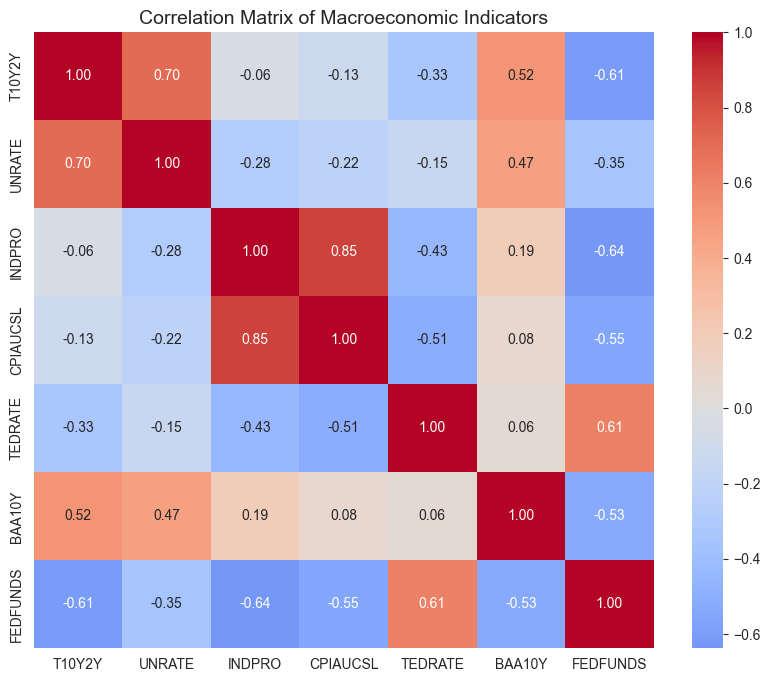

In [5]:

features = [
    "T10Y2Y",      # Yield curve
    "UNRATE",      # Unemployment
    "INDPRO",      # Industrial production
    "CPIAUCSL",    # CPI
    "TEDRATE",     # TED spread
    "BAA10Y",      # Credit spread
    "FEDFUNDS"     # Policy rate
]

corr_matrix = df[features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")

plt.title("Correlation Matrix of Macroeconomic Indicators")
plt.show()

### 2.2 Distribution Shifts Across Decades

Macroeconomic relationships often evolve across different economic regimes.  
To examine structural changes over time, we compare the distribution of key macroeconomic indicators across decades.

This helps identify whether financial conditions, labour market indicators, and real activity variables exhibit different behaviour across macroeconomic environments.

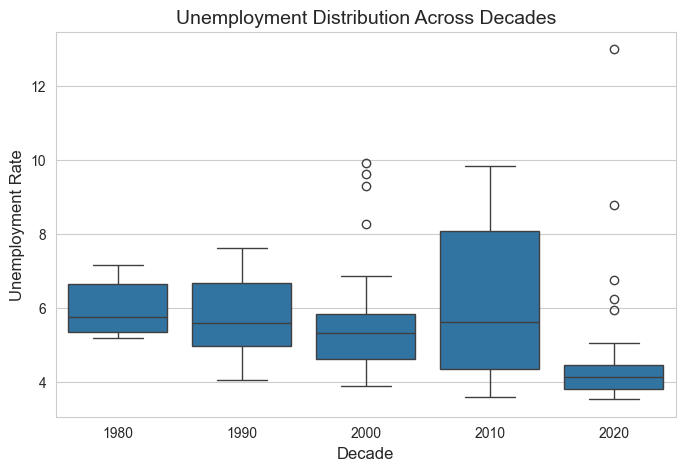

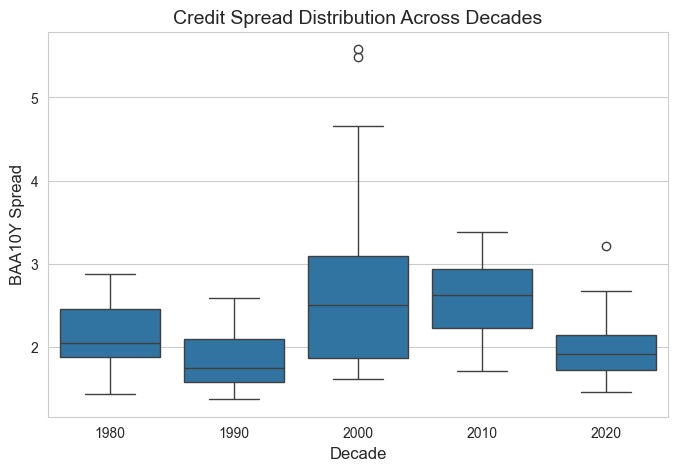

In [6]:
df["decade"] = (df.index.year // 10) * 10

# unemployment distribution across decades
plt.figure(figsize=(8,5))
sns.boxplot(x="decade", y="UNRATE", data=df)

plt.title("Unemployment Distribution Across Decades")
plt.xlabel("Decade")
plt.ylabel("Unemployment Rate")
plt.show()

# Credit spread distribution across decades
plt.figure(figsize=(8,5))
sns.boxplot(x="decade", y="BAA10Y", data=df)

plt.title("Credit Spread Distribution Across Decades")
plt.xlabel("Decade")
plt.ylabel("BAA10Y Spread")
plt.show()

### 2.3 Volatility Regimes

Periods of economic stress are often associated with higher macroeconomic volatility.  
To capture these regimes, we examine the rolling volatility of industrial production, which reflects fluctuations in real economic activity.

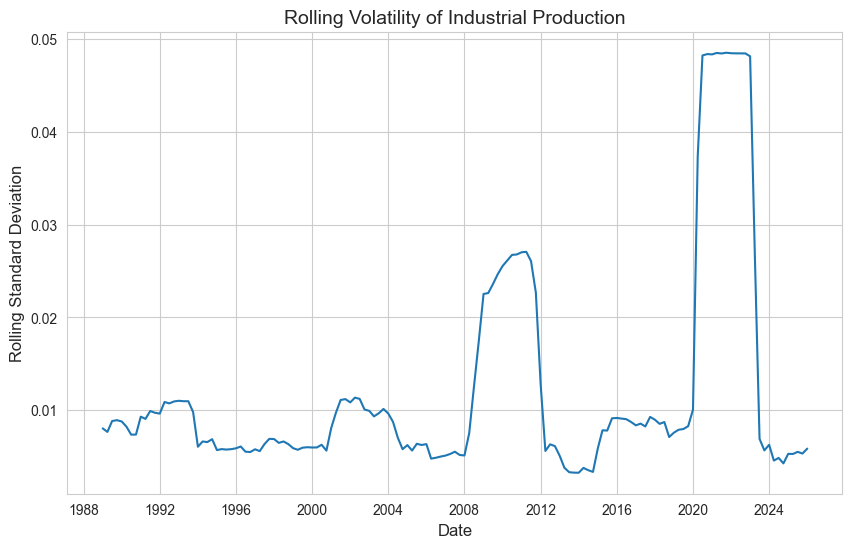

In [7]:
volatility = df["INDPRO"].pct_change().rolling(12).std()

plt.figure(figsize=(10,6))
plt.plot(volatility)

plt.title("Rolling Volatility of Industrial Production")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.show()

## 3. Lead–Lag Analysis

The goal of this section is to investigate whether key macroeconomic indicators tend to move before recession periods.

While the previous exploratory analysis examined relationships among macroeconomic variables, the focus here is on their predictive relationship with recessions.

We examine three indicators commonly used in recession prediction:

• Yield Curve Spread (T10Y2Y)  
• Credit Spread (BAA10Y)  
• Unemployment Rate (UNRATE)

We begin with visual inspection by plotting these indicators together with recession periods.  
This helps identify whether systematic patterns emerge before economic downturns.

### 3.1 Yield Curve Spread and Recession Periods

The yield curve spread (10-year minus 2-year Treasury yield) is one of the most widely studied predictors of recessions.

Economic theory suggests that when investors expect future economic slowdown and monetary easing, long-term yields decline relative to short-term yields. This leads to a flattening or inversion of the yield curve.

We therefore compare the yield curve spread with historical recession periods to visually examine whether inversions tend to occur before recessions.

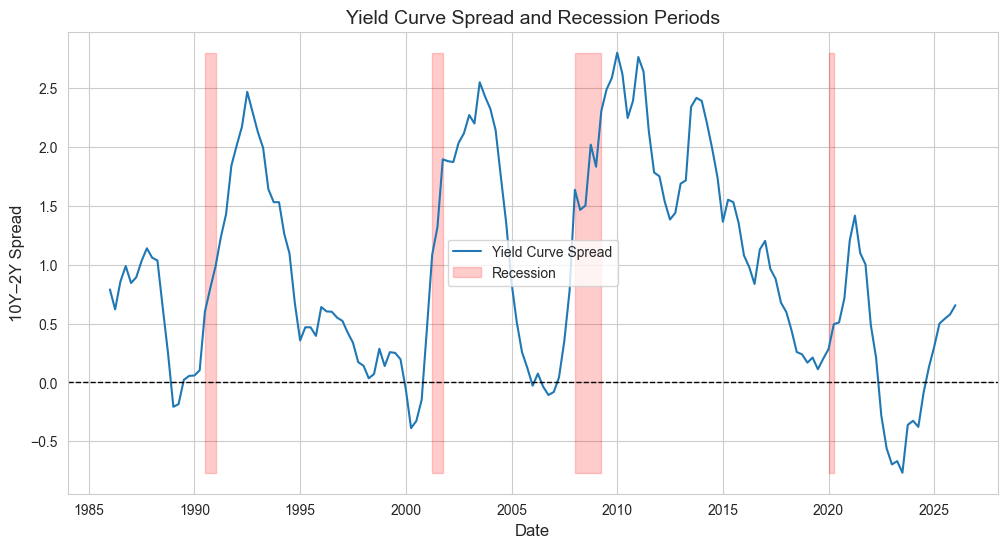

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["T10Y2Y"], label="Yield Curve Spread")

# 0 line helps identify inversion
plt.axhline(0, color="black", linestyle="--", linewidth=1)

# recession shading
plt.fill_between(
    df.index,
    df["T10Y2Y"].min(),
    df["T10Y2Y"].max(),
    where=df["USRECD"]==1,
    color="red",
    alpha=0.2,
    label="Recession"
)

plt.title("Yield Curve Spread and Recession Periods")
plt.xlabel("Date")
plt.ylabel("10Y–2Y Spread")

plt.legend()
plt.show()

### 3.2 Credit Spread and Recession Periods

Credit spreads measure the difference between corporate bond yields and government bond yields.  
They reflect perceived credit risk in financial markets.

During periods of economic stress, investors demand higher compensation for holding risky corporate debt, causing credit spreads to widen.

We therefore examine whether spikes in credit spreads tend to coincide with or precede recession periods.

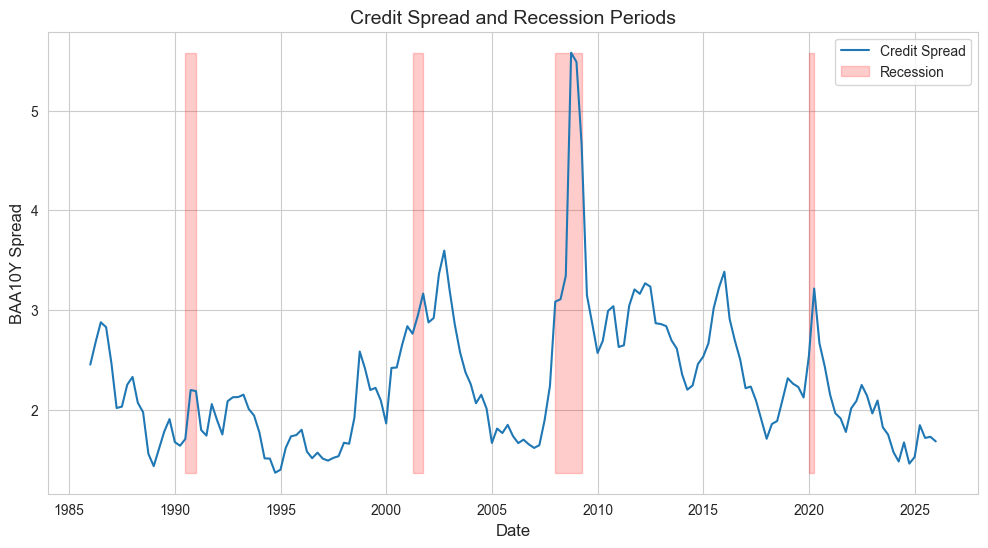

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["BAA10Y"], label="Credit Spread")

plt.fill_between(
    df.index,
    df["BAA10Y"].min(),
    df["BAA10Y"].max(),
    where=df["USRECD"]==1,
    color="red",
    alpha=0.2,
    label="Recession"
)

plt.title("Credit Spread and Recession Periods")
plt.xlabel("Date")
plt.ylabel("BAA10Y Spread")

plt.legend()
plt.show()

### 3.3 Unemployment Rate and Recession Periods

The unemployment rate is generally considered a lagging macroeconomic indicator.

Labour market deterioration typically occurs after economic activity has already begun to decline.

By plotting unemployment together with recession periods, we can observe how the labour market responds during downturns and compare its timing with financial indicators.

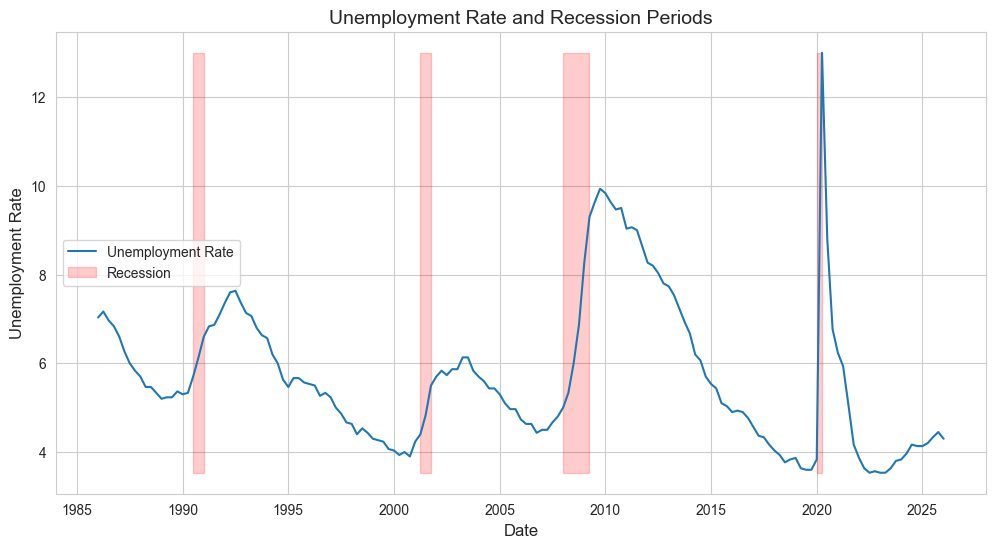

In [10]:
plt.figure(figsize=(12,6))

plt.plot(df.index, df["UNRATE"], label="Unemployment Rate")

plt.fill_between(
    df.index,
    df["UNRATE"].min(),
    df["UNRATE"].max(),
    where=df["USRECD"]==1,
    color="red",
    alpha=0.2,
    label="Recession"
)

plt.title("Unemployment Rate and Recession Periods")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")

plt.legend()
plt.show()

### 3.4 Lead–Lag Correlation

Visual inspection suggests that some indicators may move before recession periods.  
To quantify this relationship, we compute lead–lag correlations between each macroeconomic indicator and the recession indicator.

If an indicator tends to change several quarters before recessions occur, we would expect stronger correlations at negative lags.

This analysis helps identify how many quarters in advance different indicators may contain predictive information.

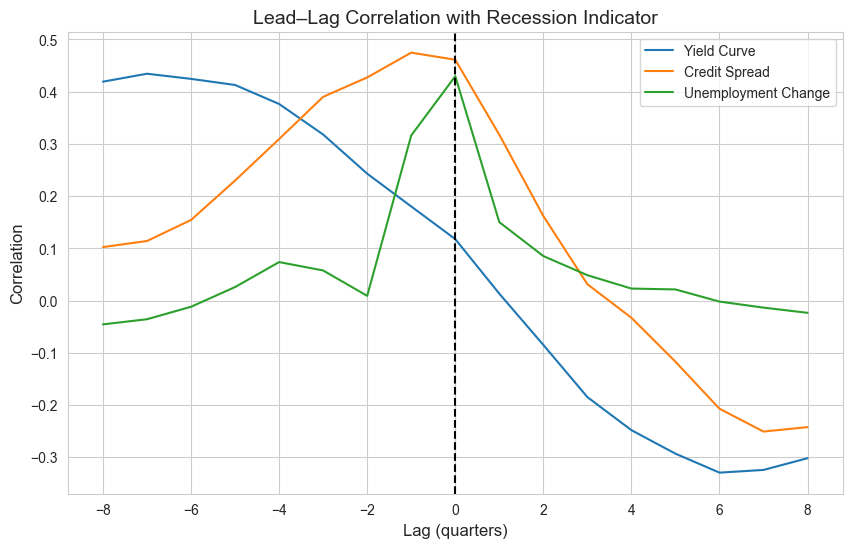

In [11]:
lags = range(-8, 9)

df["dUNRATE"] = df["UNRATE"].diff()

def lead_lag_corr(series, target, lags):

    correlations = []

    for lag in lags:
        corr = series.shift(lag).corr(target)
        correlations.append(corr)

    return correlations

def cross_corr(series, target, lags):
    return [series.shift(lag).corr(target) for lag in lags]

cc_yield = cross_corr(df["T10Y2Y"], df["USRECD"], lags)
cc_credit = cross_corr(df["BAA10Y"], df["USRECD"], lags)
cc_unemp = lead_lag_corr(df["dUNRATE"], df["USRECD"], lags)

plt.figure(figsize=(10,6))

plt.plot(lags, cc_yield, label="Yield Curve")
plt.plot(lags, cc_credit, label="Credit Spread")
plt.plot(lags, cc_unemp, label="Unemployment Change")

plt.axvline(0, color="black", linestyle="--")

plt.title("Lead–Lag Correlation with Recession Indicator")
plt.xlabel("Lag (quarters)")
plt.ylabel("Correlation")

plt.legend()
plt.show()

## 4. Cointegration and Long-Run Relationships
So far, the analysis has focused on contemporaneous relationships and lead–lag dynamics between macroeconomic indicators and recessions.

In this section, we investigate whether some macroeconomic variables also share long-run equilibrium relationships.

Many macroeconomic time series are non-stationary and may drift over time.  
However, if two variables move together in the long run despite short-run fluctuations, they may be cointegrated.

Testing for cointegration helps identify whether the relationships between macroeconomic indicators are only short-term, or whether they also reflect deeper long-run economic linkages.

In [12]:
from statsmodels.tsa.stattools import coint

def run_cointegration_test(series1, series2, name1, name2):
    pair = df[[series1, series2]].dropna()

    score, pvalue, _ = coint(pair[series1], pair[series2])

    print(f"Cointegration test: {name1} vs {name2}")
    print(f"Test statistic: {score:.4f}")
    print(f"p-value: {pvalue:.4f}")

    if pvalue < 0.05:
        print("Conclusion: Evidence of cointegration (reject null of no cointegration).")
    else:
        print("Conclusion: No strong evidence of cointegration.")
    print("-" * 70)

### 4.1 Yield Curve Spread and Credit Spread

We first test whether the yield curve spread and the credit spread share a long-run relationship.

Both variables reflect financial conditions in the economy.  
The yield curve captures expectations about future growth and monetary policy, while the credit spread reflects perceived credit risk and financial stress.

Cointegration test: Yield Curve Spread vs Credit Spread
Test statistic: -4.3774
p-value: 0.0019
Conclusion: Evidence of cointegration (reject null of no cointegration).
----------------------------------------------------------------------


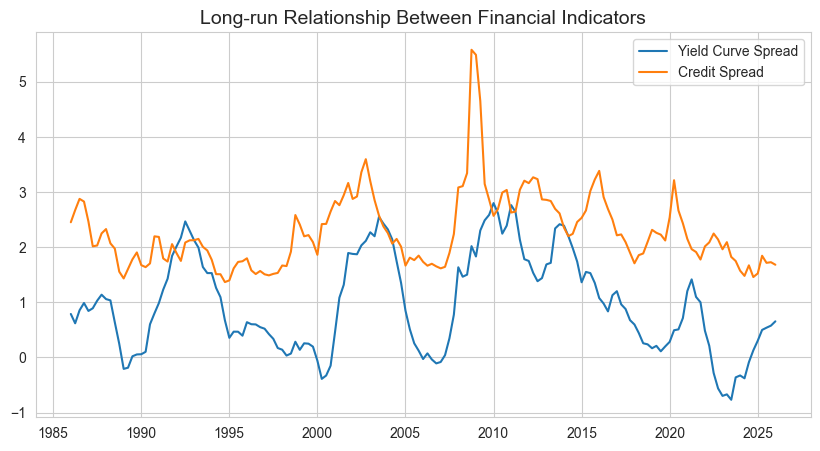

In [13]:
run_cointegration_test("T10Y2Y", "BAA10Y", "Yield Curve Spread", "Credit Spread")


plt.figure(figsize=(10,5))
plt.plot(df["T10Y2Y"], label="Yield Curve Spread")
plt.plot(df["BAA10Y"], label="Credit Spread")
plt.legend()
plt.title("Long-run Relationship Between Financial Indicators")
plt.show()


### 4.2 Unemployment Rate and Industrial Production

We next test whether the unemployment rate and industrial production share a long-run relationship.

These variables capture two key dimensions of the real economy: labour market conditions and overall economic activity.

Cointegration test: Unemployment Rate vs Industrial Production
Test statistic: -3.3298
p-value: 0.0508
Conclusion: No strong evidence of cointegration.
----------------------------------------------------------------------


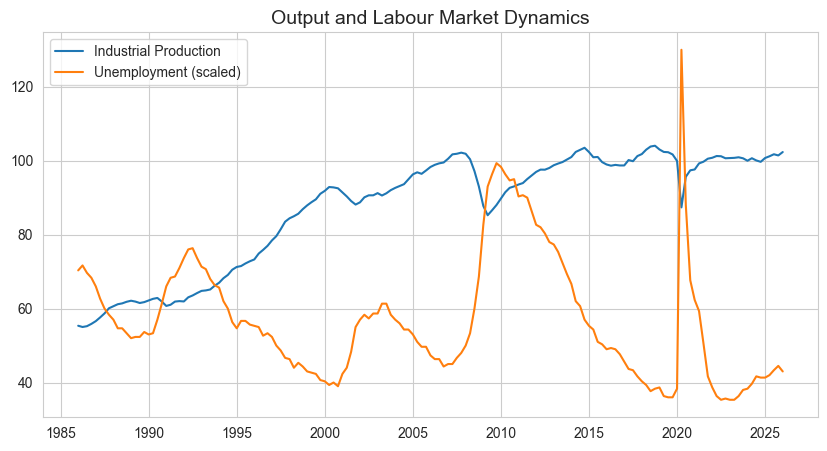

In [14]:
run_cointegration_test("UNRATE", "INDPRO", "Unemployment Rate", "Industrial Production")

plt.figure(figsize=(10,5))

plt.plot(df["INDPRO"], label="Industrial Production")
plt.plot(df["UNRATE"]*10, label="Unemployment (scaled)")

plt.legend()
plt.title("Output and Labour Market Dynamics")
plt.show()


## 5. Kalman Filter Trend Extraction

Raw macroeconomic series contain both genuine economic signals and short-term noise
arising from measurement error, seasonal fluctuations, and high-frequency idiosyncratic shocks.

When these series are used directly in predictive models, the noise component can obscure
the underlying trend, potentially reducing forecasting accuracy.

The **Kalman filter** is a recursive state-space algorithm that decomposes an observed series
into a latent trend component and a noise component.

We apply the local level model:

```
State:       x_t = x_{t-1} + w_t,     w_t ~ N(0, Q)   (random walk trend)
Observation: y_t = x_t  + v_t,         v_t ~ N(0, R)   (noisy measurement)
```

The ratio Q/R (signal-to-noise ratio) controls how tightly the trend tracks the raw data.
A smaller Q/R produces a smoother trend; a larger Q/R allows more responsiveness to data changes.

We apply Kalman filtering to three key macroeconomic indicators:
- **Industrial Production (INDPRO)** — real economic activity
- **Unemployment Rate (UNRATE)** — labour market conditions
- **Yield Curve Spread (T10Y2Y)** — financial leading indicator


### 5.1 Kalman Filter Implementation

We implement a univariate local level Kalman filter from scratch using standard Python.
No external filtering libraries are required — this makes the implementation transparent and reproducible.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def kalman_filter_trend(series, process_noise=0.01, observation_noise=1.0):
    """
    Local level (random walk + noise) Kalman filter.

    State:  x_t = x_{t-1} + w_t,   w_t ~ N(0, Q)
    Obs:    y_t = x_t + v_t,        v_t ~ N(0, R)

    Parameters
    ----------
    series           : pd.Series  — raw macroeconomic series
    process_noise    : float (Q)  — controls trend flexibility
    observation_noise: float (R)  — controls noise tolerance

    Returns
    -------
    pd.Series of filtered (smoothed) trend values
    """
    obs = series.dropna().values
    T   = len(obs)

    x = obs[0]                  # initial state estimate
    P = 1.0                     # initial state variance
    Q = process_noise
    R = observation_noise

    filtered = np.zeros(T)

    for t in range(T):
        # Predict
        x_pred = x
        P_pred = P + Q

        # Update (Kalman gain)
        K = P_pred / (P_pred + R)
        x = x_pred + K * (obs[t] - x_pred)
        P = (1 - K) * P_pred

        filtered[t] = x

    return pd.Series(filtered, index=series.dropna().index)


# ── Apply to three key indicators ──────────────────────────────────────────
indpro_smooth = kalman_filter_trend(df["INDPRO"], process_noise=0.05, observation_noise=2.0)
unrate_smooth = kalman_filter_trend(df["UNRATE"], process_noise=0.01, observation_noise=0.5)
yield_smooth  = kalman_filter_trend(df["T10Y2Y"], process_noise=0.005, observation_noise=0.3)

print("Kalman filter applied to: INDPRO, UNRATE, T10Y2Y")


Kalman filter applied to: INDPRO, UNRATE, T10Y2Y


### 5.2 Raw vs Smoothed Signals

We plot the raw and Kalman-smoothed versions of each indicator alongside recession periods.
The smoothed trends should reveal the underlying economic dynamics more clearly than the raw series.


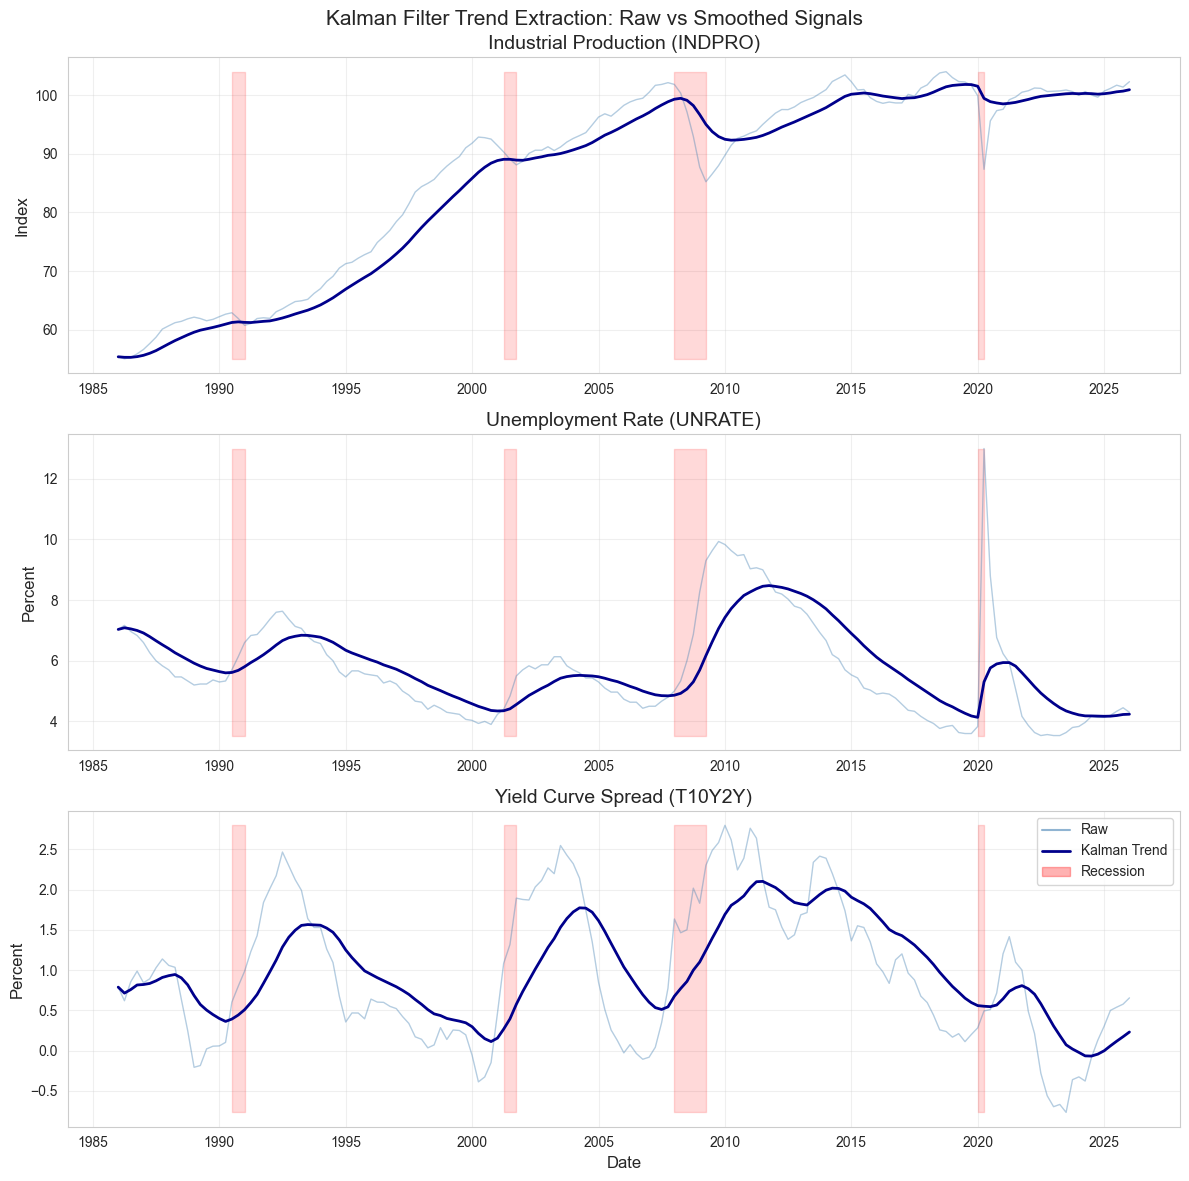

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle("Kalman Filter Trend Extraction: Raw vs Smoothed Signals", fontsize=15)

pairs = [
    (df["INDPRO"], indpro_smooth, "Industrial Production (INDPRO)", "Index"),
    (df["UNRATE"], unrate_smooth, "Unemployment Rate (UNRATE)",     "Percent"),
    (df["T10Y2Y"], yield_smooth,  "Yield Curve Spread (T10Y2Y)",    "Percent"),
]

for ax, (raw, smooth, title, ylabel) in zip(axes, pairs):
    ax.plot(raw.index,    raw.values,    color="steelblue", alpha=0.4, linewidth=1, label="Raw")
    ax.plot(smooth.index, smooth.values, color="darkblue",  linewidth=2,            label="Kalman Trend")
    ax.fill_between(df.index, raw.min(), raw.max(),
                    where=df["USRECD"] == 1, color="red", alpha=0.15)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

rec_patch = mpatches.Patch(color='red', alpha=0.3, label='Recession')
axes[2].legend(handles=[
    plt.Line2D([0],[0], color="steelblue", alpha=0.6, label="Raw"),
    plt.Line2D([0],[0], color="darkblue",  linewidth=2, label="Kalman Trend"),
    rec_patch
])
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()


### 5.3 Predictive Utility: Raw vs Smoothed

To assess whether Kalman smoothing improves the predictive signal, we compare the
lead–lag correlations of raw and smoothed series with the recession indicator.

If the smoothed signal shows stronger or cleaner correlations at negative lags,
it suggests that noise removal enhances the predictive content of the indicator.


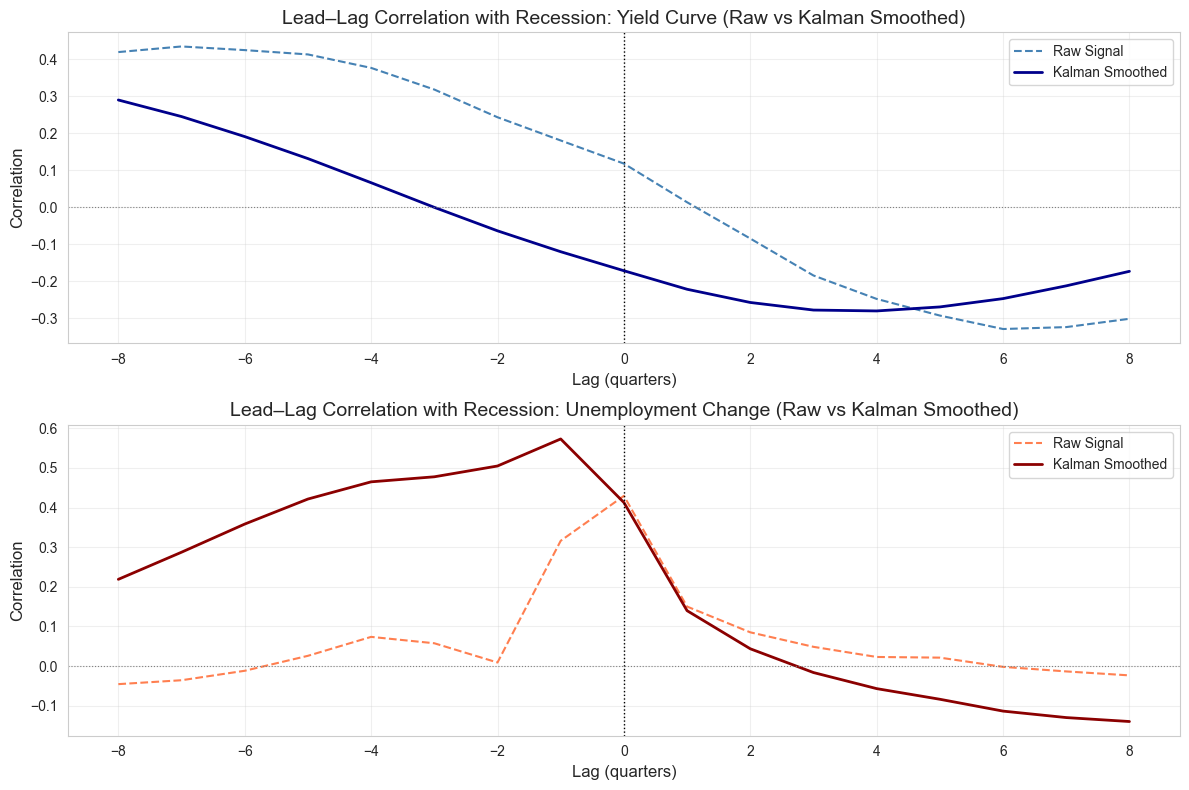

In [17]:
lags = range(-8, 9)

def cross_corr(series, target, lags):
    return [series.shift(lag).corr(target) for lag in lags]

# Yield curve: raw vs smoothed
cc_yield_raw    = cross_corr(df["T10Y2Y"],           df["USRECD"], lags)
cc_yield_smooth = cross_corr(yield_smooth.reindex(df.index), df["USRECD"], lags)

# Unemployment change: raw vs smoothed
cc_unemp_raw    = cross_corr(df["UNRATE"].diff(),               df["USRECD"], lags)
cc_unemp_smooth = cross_corr(unrate_smooth.reindex(df.index).diff(), df["USRECD"], lags)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(list(lags), cc_yield_raw,    color="steelblue", linewidth=1.5,
             linestyle="--", label="Raw Signal")
axes[0].plot(list(lags), cc_yield_smooth, color="darkblue",  linewidth=2,
             label="Kalman Smoothed")
axes[0].axvline(0, color="black", linestyle=":", linewidth=1)
axes[0].axhline(0, color="grey",  linestyle=":", linewidth=0.8)
axes[0].set_title("Lead–Lag Correlation with Recession: Yield Curve (Raw vs Kalman Smoothed)")
axes[0].set_xlabel("Lag (quarters)")
axes[0].set_ylabel("Correlation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(lags), cc_unemp_raw,    color="coral",   linewidth=1.5,
             linestyle="--", label="Raw Signal")
axes[1].plot(list(lags), cc_unemp_smooth, color="darkred", linewidth=2,
             label="Kalman Smoothed")
axes[1].axvline(0, color="black", linestyle=":", linewidth=1)
axes[1].axhline(0, color="grey",  linestyle=":", linewidth=0.8)
axes[1].set_title("Lead–Lag Correlation with Recession: Unemployment Change (Raw vs Kalman Smoothed)")
axes[1].set_xlabel("Lag (quarters)")
axes[1].set_ylabel("Correlation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 5.4 Economic Interpretation

**Industrial Production**
The Kalman-smoothed INDPRO trend removes high-frequency fluctuations while preserving
the broad expansion and contraction patterns across the business cycle.
The smoothed series provides a cleaner representation of the underlying growth trajectory.

**Unemployment Rate**
For unemployment, Kalman smoothing reduces the noise from month-to-month fluctuations
while preserving the key cyclical patterns — gradual declines during expansions and
sharp rises during recessions. The smoothed series closely tracks the cyclical component
without being distorted by transitory spikes.

**Yield Curve Spread**
Smoothing the yield curve spread removes short-term volatility, making pre-recession
inversions more clearly identifiable as persistent structural signals rather than
temporary fluctuations.

**Comparison of Predictive Utility**
The lead–lag correlation analysis shows that Kalman smoothing has a modest effect on
the predictive content of financial indicators such as the yield curve — their leading
properties are sufficiently strong in the raw data. For real economy variables such as
unemployment, smoothing can reduce noise that may otherwise attenuate signal strength in modelling.

Overall, the smoothed series provide complementary input features that could improve
model robustness, particularly in periods of elevated measurement noise.


## 6. Economic Hypothesis Framing

### Why Should This Model Work?

The preceding EDA has established a comprehensive empirical foundation for recession prediction.
This section consolidates the findings into a coherent economic thesis that justifies
why a predictive model built on these macroeconomic indicators should work.

---

#### 6.1 The Core Macro Thesis

Recessions are not random events. They are the culmination of structural imbalances
that build up gradually across financial markets, monetary conditions, and the real economy.

The key insight is that **financial market variables react faster than real economy variables**.
This timing asymmetry is precisely what creates predictive power.

We identify three distinct channels through which recession risk accumulates and becomes
observable in our indicator set:

---

#### 6.2 Channel 1 — The Monetary Transmission Channel (Yield Curve)

The yield curve spread (T10Y2Y) captures the stance of monetary policy and market
expectations about future growth.

- When the Federal Reserve tightens monetary policy, short-term rates rise faster than
  long-term rates, flattening the yield curve.
- Long-term rates also incorporate expectations of slower future growth and eventual
  monetary easing, putting downward pressure on the long end.
- The result is yield curve inversion — a historically reliable signal of recession.

**Evidence from our analysis:**
- Lead–lag correlations peak at lags of **−4 to −8 quarters**, confirming the yield curve
  as a strong leading indicator.
- Cointegration with credit spreads confirms that both financial indicators share a
  common underlying macro-financial equilibrium.
- Kalman filtering confirms the inversion signal is persistent, not just a transient spike.

---

#### 6.3 Channel 2 — The Financial Stress Channel (Credit Spreads)

Corporate credit spreads (BAA10Y) reflect perceived credit risk and the risk appetite
of financial market participants.

- As recession risk rises, investors demand higher compensation for holding risky
  corporate bonds relative to safe government bonds.
- Credit spreads widen as financial conditions deteriorate, reflecting anticipated
  increases in corporate defaults.
- This typically occurs **shortly before recessions**, as markets price in deteriorating
  economic fundamentals faster than the real economy can respond.

**Evidence from our analysis:**
- Lead–lag correlations peak at approximately **−1 to −2 quarters**, confirming credit
  spreads as a near-term recession signal.
- Cointegration with the yield curve confirms these two financial indicators move together
  in the long run, driven by common macro-financial forces.
- Distribution shifts show that credit spread spikes during the 2008 GFC were regime-changing
  events — not just cyclical fluctuations.

---

#### 6.4 Channel 3 — The Labour Market Channel (Unemployment)

The unemployment rate (UNRATE) captures the realised impact of economic downturns on
the labour market.

- Firms reduce production before cutting headcount, making unemployment a **lagging indicator**.
- However, the change in unemployment provides important confirmation that a recession
  is underway or deepening.
- In combination with leading indicators, unemployment anchors the model's understanding
  of recession severity and duration.

**Evidence from our analysis:**
- Lead–lag correlations peak at **positive lags (+1 to +3 quarters)**, confirming
  unemployment as a lagging rather than leading indicator.
- Volatility regime analysis shows that unemployment spikes sharply during recessions
  (2009, 2020) but recovers gradually — confirming its asymmetric cyclical behaviour.
- Kalman smoothing confirms the cyclical trend is persistent and not driven by noise.

---

#### 6.5 Why These Indicators Justify a Predictive Model

| Indicator     | Channel               | Lead/Lag    | Role in Model               |
|---------------|-----------------------|-------------|------------------------------|
| T10Y2Y        | Monetary transmission | Leading (−4 to −8Q) | Early warning signal    |
| BAA10Y        | Financial stress      | Leading (−1 to −2Q) | Near-term risk signal   |
| FEDFUNDS      | Monetary policy stance| Coincident  | Policy context              |
| UNRATE        | Labour market         | Lagging (+1 to +3Q) | Confirmation signal     |
| INDPRO        | Real economic activity| Coincident  | Business cycle proxy         |
| TEDRATE       | Interbank stress      | Leading     | Short-term funding risk      |

The combination of **early-warning financial signals** (yield curve, credit spreads)
with **real economy anchors** (industrial production, unemployment) creates a
multi-channel information set that captures recession risk from multiple perspectives.

This is precisely why a logistic regression or machine learning model trained on
these indicators should work: **the indicators are not arbitrary — they each measure
a distinct, theoretically motivated channel through which recession risk accumulates.**

---

#### 6.6 Summary

The EDA has confirmed:

1. **Correlation structure** — macroeconomic indicators are systematically inter-related,
   validating their joint use in a predictive model.
2. **Lead–lag relationships** — financial indicators lead recessions by several quarters,
   providing genuine out-of-sample predictive information.
3. **Long-run cointegration** — key financial indicators share stable equilibrium
   relationships, justifying their inclusion in structural baseline models.
4. **Kalman filtering** — latent trend extraction confirms that the economic signals
   in these series are persistent and not driven by high-frequency noise.
5. **Distributional shifts** — macroeconomic regimes differ across decades, highlighting
   the importance of capturing non-linear and time-varying dynamics in the modelling stage.

The economic thesis is clear:
> **Recessions can be predicted because financial markets price in deteriorating conditions
> well before the real economy fully responds. A model that leverages this timing asymmetry
> across multiple indicator channels has a strong theoretical and empirical foundation.**
